# Reservoir simulation using JutulDarcy

In this notebook we demostrate how to run reseroir simulation using `JutulDarcy.jl` and collect the simulation results into a `Field` model. We use  the `PyJutulDarcy` python wrapper (https://github.com/sintefmath/PyJutulDarcy) to interact between `Field`  and `JutulDarcy`. The package `PyJutulDarcy` sould be installed separately: 
```
pip install jutuldarcy
```
Note that when using this notebook for the first time, `Julia` will be installed and compiled automatically.

The following workflow consists of several steps:
* loading the reservoir model using `PyJutulDarcy`;
* running simulation in `PyJutulDarcy`; results are python dicts and numpy arrays;
* loading the reservoir model using `DeepField`;
* assigning dynamical arrays to the `Field` model.

Required imports:

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import timedelta
import matplotlib.pyplot as plt
import jutuldarcy as jd
from juliacall import Main as jl

import sys
sys.path.append("..")

from deepfield import Field

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Specify path to `.DATA` file containing reservoir model

In [2]:
path = '../open_data/egg/Egg_Model_ECL.DATA'

`PyJutulDarcy` reads `.DATA` file and converts data into a `Jutul` data structure containing following fields: 

- `dt` - report steps
- `forces` - control and boundary values
- `input_data` - dict-like data structure containing sections of the `.DATA` file (see below)
- `model` - variables and equations used in simulation
- `parameters` - parameters of the model to which can be computed sensitivities
- `state0` - initial state

In [3]:
case = jd.setup_case_from_data_file(path)
case.input_data

Dict{String, Any} with 7 entries:
  "RUNSPEC"  => OrderedDict{String, Any}("TITLE"=>"Egg_Model", "UNIFOUT"=>true,…
  "GRID"     => OrderedDict{String, Any}("cartDims"=>(60, 60, 7), "CURRENT_BOX"…
  "REGIONS"  => OrderedDict{String, Any}()
  "PROPS"    => OrderedDict{String, Any}("DENSITY"=>Any[[900.0, 1000.0, 1.0]], …
  "SUMMARY"  => OrderedDict{String, Any}()
  "SCHEDULE" => Dict{String, Any}("STEPS"=>OrderedDict{String, Any}[OrderedDict…
  "SOLUTION" => OrderedDict{String, Any}("EQUIL"=>Any[[4000.0, 4.0e7, 5000.0, 0…

Now we run model simulation using `PyJutulDarcy`

In [4]:
res = jd.simulate_data_file(path, convert=True, info_level=-1)

Result is a python dictionary that stores information about control and states per report timestep as regular `ndarray`:

In [5]:
res.keys()

dict_keys(['WELLS', 'FIELD', 'DAYS', 'STATES'])

For example, the `STATES` key is a list of length the number of report steps, with a dictionary for each time step:

In [6]:
len(res['STATES'])

120

In [7]:
res['STATES'][0].keys()

dict_keys(['Saturations', 'Pressure', 'TotalMasses'])

Below is an example of `ndarray` with values of saturations at the first timestep (remember initial state is not returned by `jd.simulate_data_file` for state and wells)

In [8]:
res['STATES'][0]['Saturations'].shape

(2, 18553)

`WELLS` key is slightly different. Its keys are well names:

In [9]:
res['WELLS'].keys()

dict_keys(['PROD2', 'INJECT5', 'INJECT4', 'INJECT2', 'INJECT1', 'PROD1', 'PROD4', 'INJECT6', 'INJECT7', 'INJECT3', 'PROD3', 'INJECT8'])

and each well contain production rates

In [10]:
res['WELLS']['PROD1'].keys()

dict_keys(['WWPT', 'WWIR', 'WGPR', 'WOIT', 'WOPT', 'WBHP', 'WWCT', 'WOIR', 'WGPT', 'WLPR', 'WWPR', 'WGIR', 'WGIT', 'WWIT', 'WGOR', 'WOPR'])

well rate is `ndarray` of length the number of report steps

In [11]:
res['WELLS']['PROD1']['WOPR']

array([132.22768033, 132.96844124, 133.4234874 , 133.96875998,
       137.7073083 , 145.57428096, 149.63446932, 153.75186771,
       156.22647403, 157.27856926, 156.71908812, 148.88904438,
       125.2202232 , 100.95410883,  79.67969295,  68.55132183,
        62.3758626 ,  56.77450832,  51.35677908,  45.65392898,
        38.93229749,  33.98656864,  30.52875519,  27.67712061,
        25.18886804,  23.09237966,  21.27481541,  19.72459408,
        18.47989142,  17.37096687,  16.32958974,  15.35644305,
        14.47105942,  13.64857766,  12.8795709 ,  12.16476091,
        11.5085674 ,  10.92155666,  10.39460481,   9.92714797,
         9.51703932,   9.14526282,   8.79563116,   8.46070039,
         8.13441534,   7.82366786,   7.53080805,   7.25800856,
         7.00492185,   6.77694978,   6.57261088,   6.38457481,
         6.21118419,   6.05077943,   5.90262402,   5.76460805,
         5.63530182,   5.51368858,   5.39825114,   5.28923701,
         5.1848444 ,   5.08494992,   4.9885347 ,   4.89

Note again that the simulation outputs do not contain initial state data. Therefore, to obtain the final results, we access to the preloaded `case` data structure. It uses `JuliaCall` functions to run `Julia` commands:

In [12]:
state0_pressure = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Pressure]")(case.state0)
).reshape(1, -1)

state0_sats = np.array(
    jl.seval("state0 -> state0[:Reservoir][:Saturations]")(case.state0)
).reshape(1, 2, -1)

Now lets arrange data in `jd.simulate_data_file` into arrays of shape `n_timesteps` $\times$ `n_active_cells`

In [13]:
n_steps = len(res['STATES'])
jd_pressure = np.array([res['STATES'][i]['Pressure'] for i in range(n_steps)])
jd_sats = np.array([res['STATES'][i]['Saturations'] for i in range(n_steps)])

and join them with initial states

In [14]:
jd_pressure = np.vstack([state0_pressure, jd_pressure])
jd_sats = np.vstack([state0_sats, jd_sats])

For illustration, we plot the mean pressure and saturations:

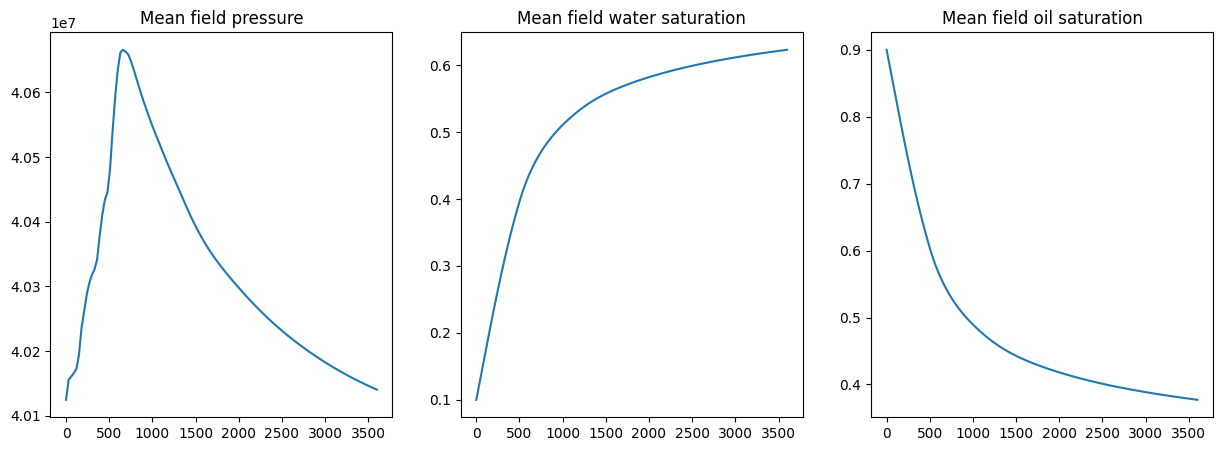

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

days = np.hstack([0., res["DAYS"]])
pressure = jd_pressure.mean(axis=1)
swat = jd_sats[:, 0, :].mean(axis=1)
soil = jd_sats[:, 1, :].mean(axis=1)

ax[0].set_title("Mean field pressure")
ax[0].plot(days, pressure)
ax[1].set_title("Mean field water saturation")
ax[1].plot(days, swat)
ax[2].set_title("Mean field oil saturation")
ax[2].plot(days, soil)

Next step is to load  `Field` model:

In [16]:
model = Field(path).load(include_binary=False)

INFO:Field:Using default config.
INFO:Field:Start reading Egg_Model_ECL.DATA
INFO:Field:Reading section RUNSPEC
INFO:Field:[Egg_Model_ECL.DATA:9] Loading TITLE
INFO:Field:[Egg_Model_ECL.DATA:16] Loading DIMENS
INFO:Field:[Egg_Model_ECL.DATA:19] Loading METRIC
INFO:Field:[Egg_Model_ECL.DATA:20] Loading OIL
INFO:Field:[Egg_Model_ECL.DATA:21] Loading WATER
INFO:Field:[Egg_Model_ECL.DATA:41] Loading START
INFO:Field:Reading section GRID
INFO:Field:[Egg_Model_ECL.DATA:55] Include C:\Users\E.Illarionov\Desktop\DP\deepfield-team\DeepField\open_data\egg\ACTIVE.INC
INFO:Field:Start reading ACTIVE.INC
INFO:Field:[ACTIVE.INC:1] Loading ACTNUM
INFO:Field:Finish reading ACTIVE.INC
INFO:Field:[Egg_Model_ECL.DATA:58] Loading DX
INFO:Field:[Egg_Model_ECL.DATA:62] Loading DY
INFO:Field:[Egg_Model_ECL.DATA:66] Loading DZ
INFO:Field:[Egg_Model_ECL.DATA:69] Loading TOPS
INFO:Field:[Egg_Model_ECL.DATA:73] Include C:\Users\E.Illarionov\Desktop\DP\deepfield-team\DeepField\open_data\egg\mDARCY.INC
INFO:Field:

Now the assing the the calculated saturation and pressure arrays to the `Field` model:

In [17]:
model.states.pressure = jd_pressure
model.states.soil = jd_sats[:, 1, :]
model.states.swat = jd_sats[:, 0, :]

Next step is to transform 1D states to 3D ones:

In [18]:
model.states.to_spatial()

Now the states can be visualized using the `show` method:

In [19]:
model.show(attr="SWAT", timestamp=20, notebook=True)

Widget(value='<iframe src="http://localhost:50381/index.html?ui=P_0x19388b0e3d0_0&reconnect=auto" class="pyvis…

For assignment of the well rate, frist extract report dates:

In [20]:
n_timestamps = len(res["DAYS"])
start_date = case.input_data["RUNSPEC"]["START"]
timestamps = [start_date + timedelta(days=res["DAYS"][i]) for i in range(n_timestamps)]
dates = pd.DataFrame({"DATE": timestamps})

Well states can be updated from the `welldata` dictionary, where the keys are well names, and the values are dataframes with the well states. Create an empty `welldata`:

In [21]:
welldata = {}

Define an auxiliary function for collecting computed well rates into dataframe:

In [22]:
def well_states(well):
    states_df = pd.concat([dates, pd.DataFrame(well)], axis=1)
    record0 = pd.DataFrame([[start_date] + [0.0]*(len(well.columns))], columns = states_df.columns)
    states_df = pd.concat([record0, states_df])
    return states_df

Collect the `welldata` dictionary:

In [23]:
wellnames = res["WELLS"].keys()
welldata = {w: {"RESULTS": well_states(pd.DataFrame(res["WELLS"][w]))} for w in wellnames}

Assign `welldata` to the `Field` using `wells.update` method:

In [24]:
model.wells.update(welldata)

Now one can use
```python
model.wells.show_rates()
``` 
to show well rates.

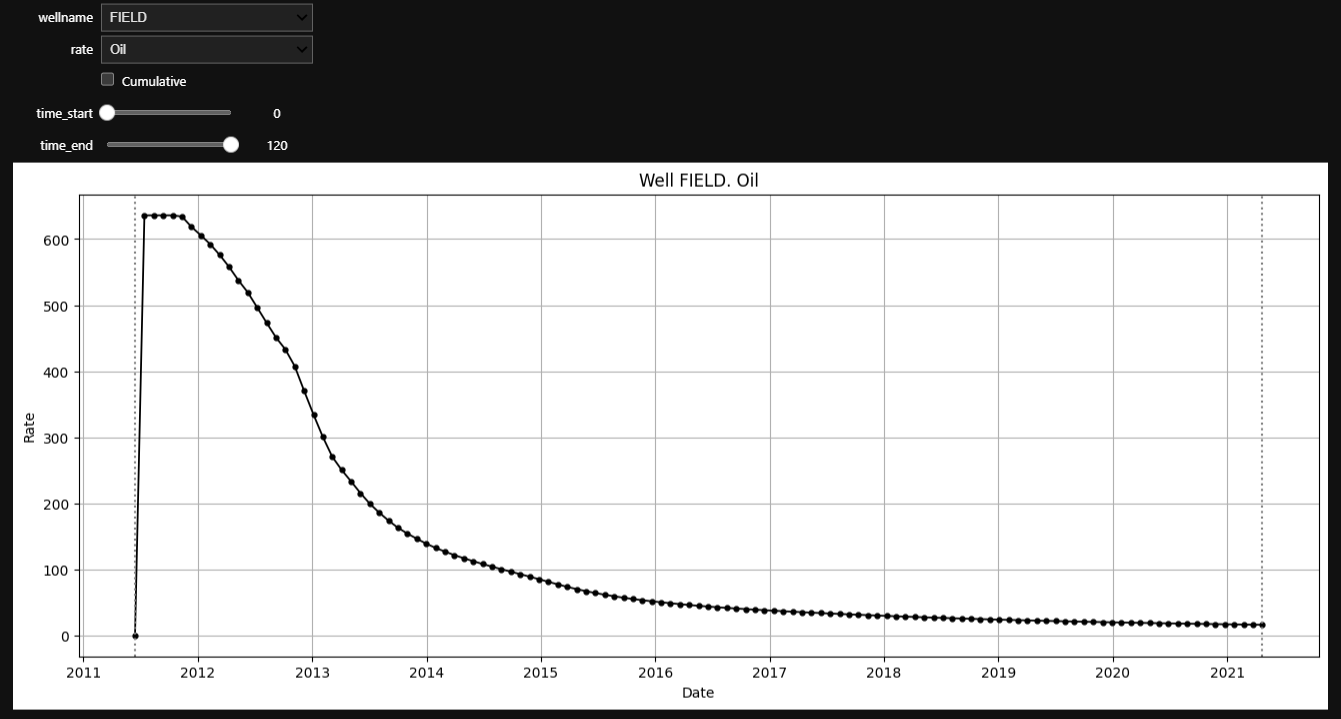

Done!